In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers

import pandas as pd
import numpy as np
import re
import torch

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# PHASE 1: Data Loading

import pandas as pd

path = "/content/drive/MyDrive/fake_job_postings.csv"

df = pd.read_csv(path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
# PHASE 2: Data Preprocessing

import re

df = df.fillna("")

df["text"] = df["title"] + " " + df["description"] + " " + df["requirements"]

def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]', '', str(text))
    text = text.lower()
    return text

df["text"] = df["text"].apply(clean_text)

df = df[["text", "fraudulent"]]

df.head()

,text,fraudulent
0,marketing intern food a fastgrowing james bear...,0
1,customer service cloud video production organ...,0
2,commissioning machinery assistant cma our clie...,0
3,account executive washington dc the company e...,0
4,bill review manager job title itemization revi...,0


In [ ]:
print(df["fraudulent"].value_counts())
print(df["text"].iloc[0][:200])

fraudulent
0    17014
1      866
Name: count, dtype: int64
marketing intern food a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small


Baseline Model Phase

In [ ]:
# PHASE 3: Train-Test Split

from sklearn.model_selection import train_test_split

X = df["text"]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14304
Testing samples: 3576


In [ ]:
# PHASE 4: TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (14304, 5000)
TF-IDF testing shape: (3576, 5000)


In [ ]:
# PHASE 5: Logistic Regression Baseline Model

from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model training completed")

Baseline model training completed


In [ ]:
# PHASE 6: Baseline Model Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

baseline_predictions = baseline_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, baseline_predictions)
precision = precision_score(y_test, baseline_predictions)
recall = recall_score(y_test, baseline_predictions)
f1 = f1_score(y_test, baseline_predictions)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.9662
Precision: 0.9815
Recall: 0.3064
F1 Score: 0.467


In [ ]:
print(classification_report(y_test, baseline_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.98      0.31      0.47       173

    accuracy                           0.97      3576
   macro avg       0.97      0.65      0.72      3576
weighted avg       0.97      0.97      0.96      3576



In [ ]:
print(confusion_matrix(y_test, baseline_predictions))

[[3402    1]
 [ 120   53]]


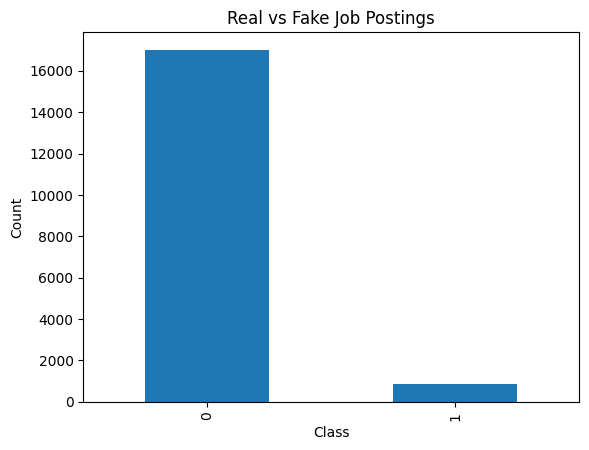

In [ ]:
# PHASE 7: Class Distribution

import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Real vs Fake Job Postings")

plt.show()

BERT transformer implementation tokenizer

In [ ]:
# PHASE 7: Install Transformer Libraries

!pip install transformers datasets -q

In [ ]:
# PHASE 8: Import Libraries

import torch
import numpy as np

from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer
from transformers import TrainingArguments

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

In [ ]:
# PHASE 9: Prepare Dataset

from sklearn.model_selection import train_test_split

X = df["text"].tolist()
y = df["fraudulent"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14304
Testing samples: 3576


In [ ]:
# PHASE 10: Load Tokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
# PHASE 11: Tokenization

train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
# PHASE 12: Create Dataset Class

class FakeJobDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
# PHASE 13: Create Train/Test Dataset

train_dataset = FakeJobDataset(train_encodings, y_train)
test_dataset = FakeJobDataset(test_encodings, y_test)

print("Train dataset ready")
print("Test dataset ready")

Train dataset ready
Test dataset ready


In [ ]:
# PHASE 14: Load BERT Model

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# PHASE 15: Evaluation Function

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
# PHASE 16: Training Configuration

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    report_to="none"
)

In [ ]:
# PHASE 17: Trainer Setup

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# PHASE 18: Start Training

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.138559,0.130740,0.971477,0.881720,0.473988,0.616541
2,0.076657,0.099726,0.979866,0.897638,0.658960,0.760000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3576, training_loss=0.11829794684145808, metrics={'train_runtime': 1531.0012, 'train_samples_per_second': 18.686, 'train_steps_per_second': 2.336, 'total_flos': 3763540535869440.0, 'train_loss': 0.11829794684145808, 'epoch': 2.0})

In [ ]:
# PHASE 19: Evaluate Transformer Model

evaluation_results = trainer.evaluate()

print(evaluation_results)

{'eval_loss': 0.09972644597291946, 'eval_accuracy': 0.9798657718120806, 'eval_precision': 0.8976377952755905, 'eval_recall': 0.6589595375722543, 'eval_f1': 0.76, 'eval_runtime': 57.64, 'eval_samples_per_second': 62.04, 'eval_steps_per_second': 7.755, 'epoch': 2.0}


In [ ]:
# PHASE 20: Prediction Example

sample_text = """
Urgently hiring remote employees.
No experience required.
Send bank details for registration.
"""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

inputs = {key: value.to(device) for key, value in inputs.items()}

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

if prediction == 1:
    print("Fake Job Posting")
else:
    print("Real Job Posting")

In [ ]:
# PHASE 21: Model Comparison

print("Baseline Logistic Regression F1 Score:", round(f1, 4))
print("Transformer BERT Model Results:")
print(evaluation_results)

Baseline Logistic Regression F1 Score: 0.467
Transformer BERT Model Results:
{'eval_loss': 0.09972644597291946, 'eval_accuracy': 0.9798657718120806, 'eval_precision': 0.8976377952755905, 'eval_recall': 0.6589595375722543, 'eval_f1': 0.76, 'eval_runtime': 57.64, 'eval_samples_per_second': 62.04, 'eval_steps_per_second': 7.755, 'epoch': 2.0}


In [ ]:
# PHASE 22: Save Model

model.save_pretrained("fake_job_bert_model")
tokenizer.save_pretrained("fake_job_bert_model")

print("Model saved successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully


Confusion Matrix:
 [[3390   13]
 [  59  114]]


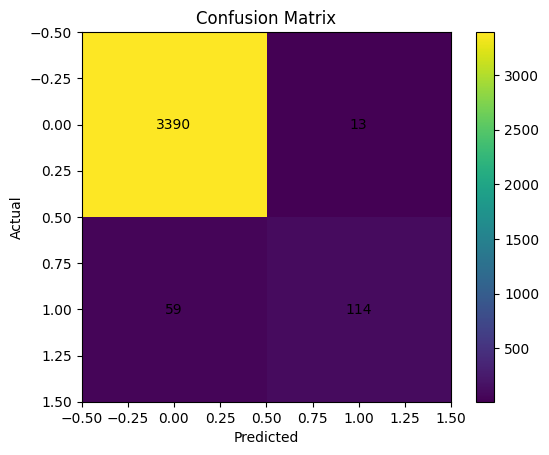

In [ ]:
# PHASE 23: Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [ ]:
# PHASE 24: Misclassified Examples

misclassified = []

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        misclassified.append((X_test[i], y_true[i], y_pred[i]))

print("Total Misclassified:", len(misclassified))

for i in range(5):
    print("\nExample", i+1)
    print("Text:", misclassified[i][0][:300])
    print("Actual:", misclassified[i][1], "| Predicted:", misclassified[i][2])

Total Misclassified: 72

Example 1
Text: maintenance specialist responsibilitiesresponsibilitiesresponsibilities shipping and receiving dock processing internal mail sorting and delivery special meeting setup and tear down will be required to work in multiple facilities when needed plan and organize work for team of associates will perform
Actual: 1 | Predicted: 0

Example 2
Text: health  environmental professional health amp environmental professionalbakersfield cathis position monitors analyzes recommends and implements systems to improve integration of environmental compliance and business success this position is part of the hse team and requires a person that is team ori
Actual: 1 | Predicted: 0

Example 3
Text: vemma brand partner looking for motivated and hard working individualsmust be at least learn entrepreneurial and reallife business skills through practicestudy success and follow successful peoplevemma is a health and nutrition company on the riseif you are looking for a g